# Yield fit plots for thesis
## Make random plots for thesis

### Turn off statistics box

In [1]:
gStyle->SetOptStat(false);

### Add BESIII style

In [2]:
gInterpreter->AddIncludePath("/data/lhcb/users/tat/KKpipi_Analysis_BESIII/include");

In [3]:
gROOT->ProcessLine(".L /data/lhcb/users/tat/KKpipi_Analysis_BESIII/src/Bes3plotstyle.cpp");

In [4]:
SetStyle();
SetPrelimStyle();

### Load $KK\pi\pi$ ST MC

In [5]:
std::string KKpipi_MC_Filename("/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins_16fb/Selection/SignalMC/");
KKpipi_MC_Filename += "SingleTag/KKpipi/KKpipi_SingleTag_SignalMC.root";
//KKpipi_MC_Filename += "SingleTag/KSpi0/KSpi0_SingleTag_SignalMC.root";
TChain KKpipi_MC_Chain("KKpipiSingleTag");
//TChain KKpipi_MC_Chain("KSpi0SingleTag");
KKpipi_MC_Chain.Add(KKpipi_MC_Filename.c_str());

### Create RooFit dataset

In [6]:
RooRealVar MBC("MBC", "", 1.83, 1.8865);
MBC.setBins(1000, "cache");
RooDataSet KKpipi_MC_DataSet("KKpipi_MC_DataSet", "", &KKpipi_MC_Chain, RooArgList(MBC));

### Create fit model using ```RooKeysPdf```

In [7]:
RooKeysPdf KKpipi_Model("KKpipi_Model", "", MBC, KKpipi_MC_DataSet);

### Plot fit model of $KK\pi\pi$ ST

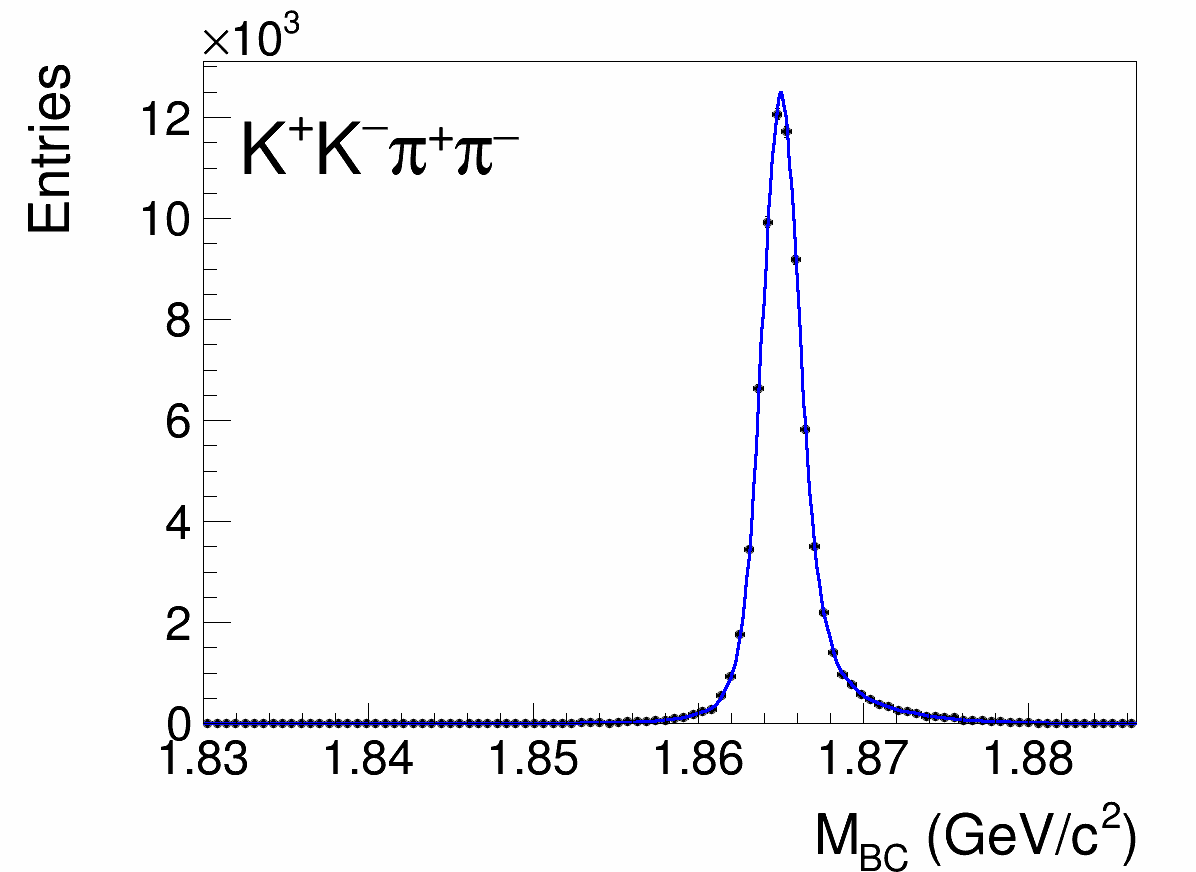

Info in <TCanvas::Print>: pdf file KKpipi_ST_RooKeysPdf.pdf has been created


In [8]:
TCanvas c1("c1", "", 1200, 900);
auto KKpipi_MBC_frame = MBC.frame();
KKpipi_MBC_frame->GetYaxis()->SetMaxDigits(3);
KKpipi_MC_DataSet.plotOn(KKpipi_MBC_frame);
KKpipi_Model.plotOn(KKpipi_MBC_frame);
KKpipi_MBC_frame->SetTitle(";M_{BC} (GeV/c^{2});Entries");
KKpipi_MBC_frame->Draw();
TLatex Text;
Text.SetTextFont(42);
Text.SetTextSize(0.09);
Text.SetTextColor(kBlack);
Text.SetNDC(true);
Text.SetText(0.2, 0.8, "K^{+}K^{#minus}#pi^{+}#pi^{#minus}");
//Text.SetText(0.2, 0.8, "K_{S}^{0}#pi^{0}");
Text.Draw("SAME");
c1.SetTopMargin(0.07);
c1.Draw();
c1.SaveAs("KKpipi_ST_RooKeysPdf.pdf");
//c1.SaveAs("KSpi0_ST_RooKeysPdf.pdf");

In [9]:
c1.Close();